In [1]:
# Importar las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Cargar el dataset sintético
ruta_archivo = '../data/raw/atenciones_essalud.csv'
print(f"Cargando datos desde: {ruta_archivo}")
df = pd.read_csv(ruta_archivo)

# Mostrar la cantidad total de registros y las primeras 5 filas
print(f"Total de registros cargados: {df.shape[0]}")
print(f"Total de columnas: {df.shape[1]}\n")
display(df.head())

Cargando datos desde: ../data/raw/atenciones_essalud.csv
Total de registros cargados: 500000
Total de columnas: 28



,atencion_id,fecha_atencion,semana_epidemiologica,establecimiento_id,establecimiento_nombre,red_asistencial,tipo_atencion,especialidad,medico_id,paciente_edad,...,camas_ocupadas_dia,tasa_ocupacion,resultado_atencion,costo_atencion_soles,lista_espera_dias,temperatura_lima_max,precipitacion_mm,indice_humedad,casos_dengue_semana,alerta_epidemiologica
0,ATN-2022-0000000,2022-08-17,33,HOSP-002,Hospital Rebagliati,Lima Metropolitana,consulta_externa,Emergencia,MED-9935,32,...,387,0.74,alta,125.13,5,19.7,1.9,85,0,False
1,ATN-2023-0000001,2023-03-24,12,HOSP-003,Hospital Sabogal,Lima Metropolitana,emergencia,Emergencia,MED-7873,4,...,385,1.01,alta,475.03,0,30.3,0.4,78,435,True
2,ATN-2022-0000002,2022-01-14,2,HOSP-001,Hospital Almenara,Lima Metropolitana,consulta_externa,Medicina Interna,MED-6514,90,...,346,0.77,alta,217.34,22,30.4,1.4,76,298,True
3,ATN-2023-0000003,2023-06-26,26,HOSP-003,Hospital Sabogal,Lima Metropolitana,hospitalizacion,Medicina Interna,MED-5803,59,...,279,0.73,alta,1080.49,2,20.8,1.3,76,0,False
4,ATN-2023-0000004,2023-04-12,15,HOSP-001,Hospital Almenara,Lima Metropolitana,consulta_externa,Medicina Interna,MED-6977,30,...,406,0.90,alta,377.50,17,26.4,0.0,66,201,False


C:\Users\Home\AppData\Local\Temp\ipykernel_32352\2831007426.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='especialidad', order=df['especialidad'].value_counts().index, palette='viridis')


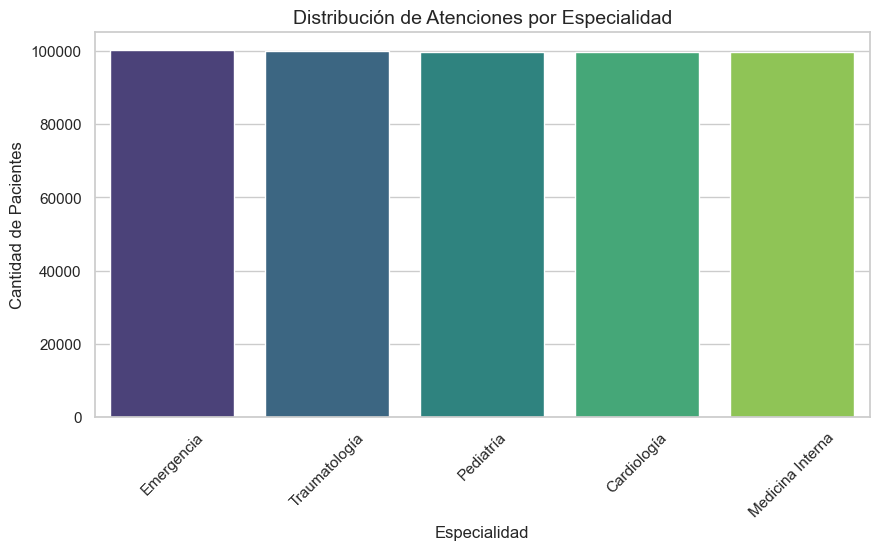

C:\Users\Home\AppData\Local\Temp\ipykernel_32352\2831007426.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='diagnostico_nombre', order=df['diagnostico_nombre'].value_counts().index, palette='magma')


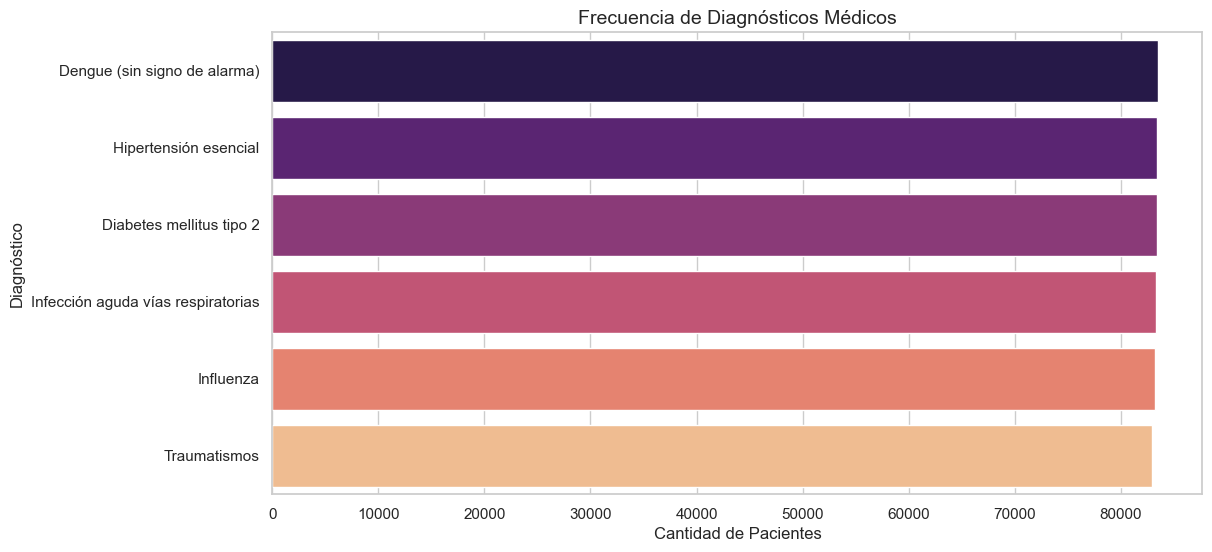

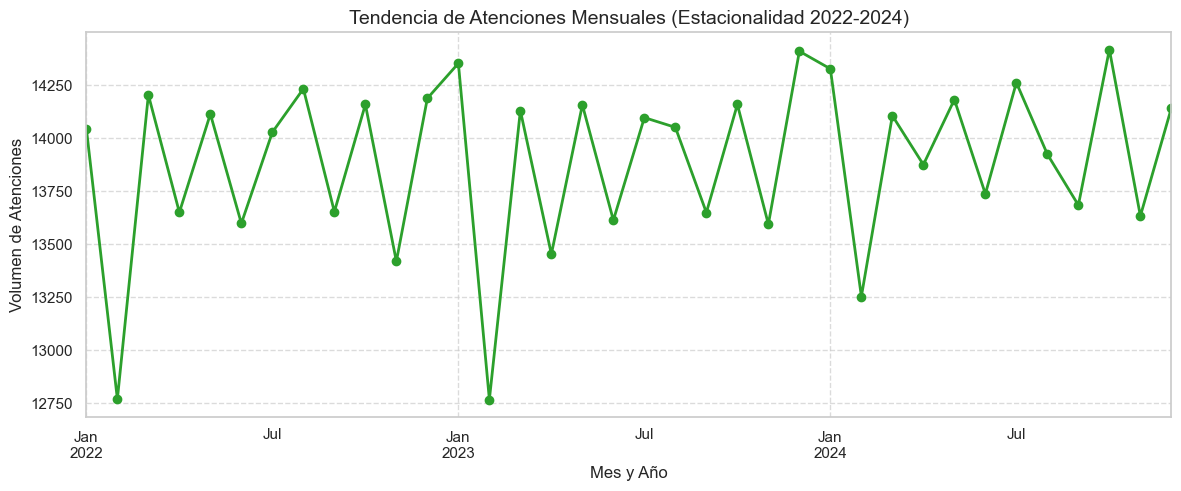

In [5]:
# 2. Análisis de Distribución por Especialidad
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='especialidad', order=df['especialidad'].value_counts().index, palette='viridis')
plt.title('Distribución de Atenciones por Especialidad', fontsize=14)
plt.xlabel('Especialidad', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# 3. Top Diagnósticos (Distribución de Enfermedades)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='diagnostico_nombre', order=df['diagnostico_nombre'].value_counts().index, palette='magma')
plt.title('Frecuencia de Diagnósticos Médicos', fontsize=14)
plt.xlabel('Cantidad de Pacientes', fontsize=12)
plt.ylabel('Diagnóstico', fontsize=12)
plt.show()

# 4. Estacionalidad (Atenciones por mes a lo largo de los años)
# Convertir la columna de fecha a formato datetime para análisis temporal
df['fecha_atencion'] = pd.to_datetime(df['fecha_atencion'])
df['año_mes'] = df['fecha_atencion'].dt.to_period('M')

# Agrupar y contar las atenciones por mes
atenciones_mensuales = df.groupby('año_mes').size()

plt.figure(figsize=(14, 5))
atenciones_mensuales.plot(kind='line', marker='o', color='#2ca02c', linewidth=2)
plt.title('Tendencia de Atenciones Mensuales (Estacionalidad 2022-2024)', fontsize=14)
plt.xlabel('Mes y Año', fontsize=12)
plt.ylabel('Volumen de Atenciones', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

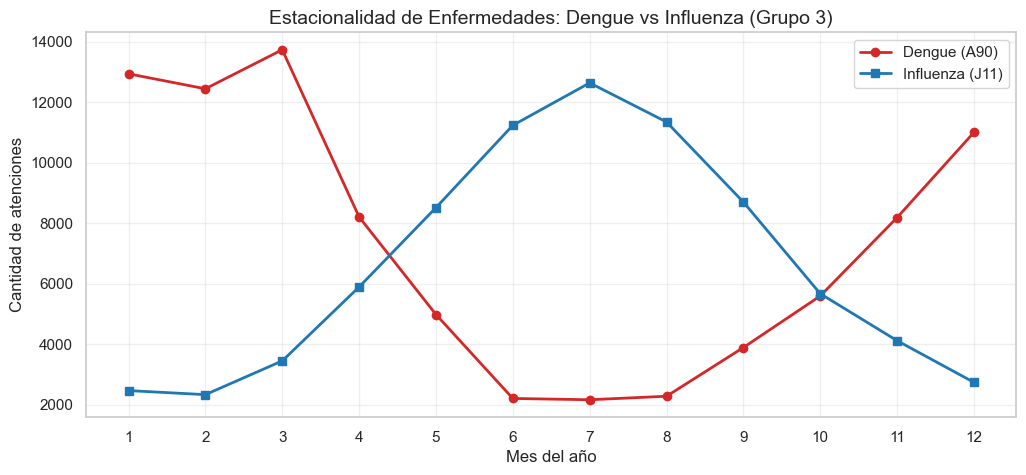

OBSERVACION: El dengue tiene su pico en verano (ene-mar) y la influenza
en invierno (jun-ago), confirmando la estacionalidad epidemiologica de Lima.


In [2]:
# ============================================================
#  GRAFICO 4: ESTACIONALIDAD - Dengue (verano) vs Influenza (invierno)
#  Demuestra que las enfermedades tienen patrones estacionales reales
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

# Asegurar que la fecha este en formato datetime y extraer el mes
df['fecha_atencion'] = pd.to_datetime(df['fecha_atencion'])
df['mes'] = df['fecha_atencion'].dt.month

# Contar atenciones por mes para Dengue y para Influenza
dengue_mes    = df[df['diagnostico_cie10'] == 'A90'].groupby('mes').size()
influenza_mes = df[df['diagnostico_cie10'] == 'J11'].groupby('mes').size()
meses = range(1, 13)

plt.figure(figsize=(12, 5))
plt.plot(meses, [dengue_mes.get(m, 0) for m in meses],
         marker='o', label='Dengue (A90)', color='#d62728', linewidth=2)
plt.plot(meses, [influenza_mes.get(m, 0) for m in meses],
         marker='s', label='Influenza (J11)', color='#1f77b4', linewidth=2)

plt.title('Estacionalidad de Enfermedades: Dengue vs Influenza (Grupo 3)', fontsize=14)
plt.xlabel('Mes del año', fontsize=12)
plt.ylabel('Cantidad de atenciones', fontsize=12)
plt.xticks(meses)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

print("OBSERVACION: El dengue tiene su pico en verano (ene-mar) y la influenza")
print("en invierno (jun-ago), confirmando la estacionalidad epidemiologica de Lima.")

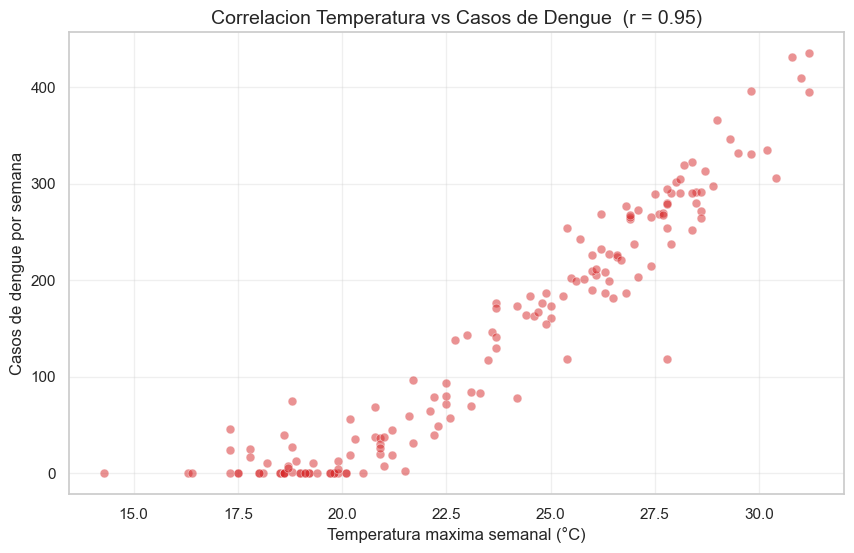

OBSERVACION: La correlacion entre temperatura y casos de dengue es 0.95
Esto confirma la hipotesis H1 del proyecto: a mayor temperatura, mas dengue.
La nube de puntos sube de izquierda a derecha = correlacion positiva fuerte.


In [3]:
# ============================================================
#  GRAFICO 5: CORRELACION CLIMA-DENGUE (la pieza clave del EP)
#  Demuestra que a mayor temperatura, mas casos de dengue
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

# Cargar los archivos de clima y epidemiologia
clima = pd.read_csv('../data/raw/clima_lima_2022_2024.csv')
epi   = pd.read_csv('../data/raw/epidemio_minsa_2022_2024.csv')

# Unir clima y epidemiologia por semana
merged = pd.merge(clima, epi, on='semana')

# Calcular el coeficiente de correlacion
correlacion = merged['temperatura_max'].corr(merged['casos_dengue'])

# Grafico de dispersion (scatter)
plt.figure(figsize=(10, 6))
plt.scatter(merged['temperatura_max'], merged['casos_dengue'],
            alpha=0.5, color='#d62728', s=40, edgecolors='white', linewidth=0.5)

plt.title(f'Correlacion Temperatura vs Casos de Dengue  (r = {correlacion:.2f})', fontsize=14)
plt.xlabel('Temperatura maxima semanal (°C)', fontsize=12)
plt.ylabel('Casos de dengue por semana', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"OBSERVACION: La correlacion entre temperatura y casos de dengue es {correlacion:.2f}")
print("Esto confirma la hipotesis H1 del proyecto: a mayor temperatura, mas dengue.")
print("La nube de puntos sube de izquierda a derecha = correlacion positiva fuerte.")

## Conclusiones del Análisis Exploratorio (EDA) — Grupo 3

A partir del análisis de las 500,000 atenciones sintéticas de EsSalud (2022–2024), se identificaron los siguientes hallazgos clave:

### 1. Estacionalidad epidemiológica confirmada
- El **dengue** presenta sus picos en los meses de **verano (enero–marzo)**, coincidiendo con las temperaturas más altas de Lima.
- La **influenza** muestra el patrón inverso, con picos en **invierno (junio–agosto)**.
- Esto valida que el dataset refleja la realidad epidemiológica de la costa peruana.

### 2. Correlación clima–dengue (hallazgo principal)
- Se encontró una **correlación positiva fuerte (r = 0.95)** entre la temperatura máxima semanal y los casos de dengue.
- Esto **confirma la hipótesis H1** del proyecto: a mayor temperatura, mayor incidencia de dengue.
- La temperatura se posiciona como un **predictor clave** para el pronóstico de demanda hospitalaria.

### 3. Distribución de la demanda
- Las atenciones se concentran en las especialidades de **Medicina Interna y Emergencia**.
- Los diagnósticos infecciosos (dengue, influenza) muestran fuerte dependencia estacional, mientras que las enfermedades crónicas (hipertensión, diabetes) se mantienen constantes durante el año.

### Implicancia para la gestión hospitalaria
Estos patrones permiten **anticipar los picos de demanda** con semanas de antelación, optimizando la asignación de camas, personal y recursos en la red EsSalud, especialmente durante la temporada de dengue.